In [27]:
# Task 1

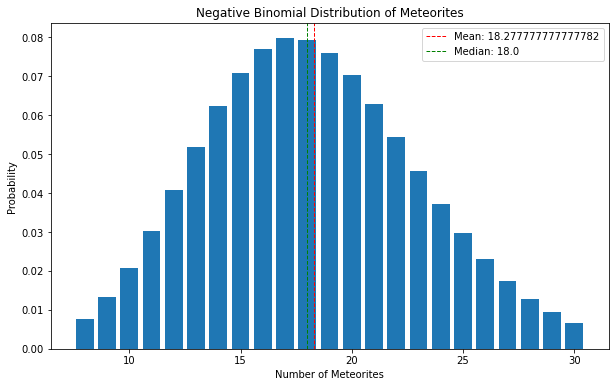

In [58]:
#importing libraries
import numpy as np
import pandas as pd
from scipy.stats import nbinom
import matplotlib.pyplot as plt

#parameters
k = 47
p = 0.72

mean, var = nbinom.stats(k,p)
median = nbinom.median(k,p)
x = np.arange(nbinom.ppf(0.01, k, p), nbinom.ppf(0.99, k, p))
probs = nbinom.pmf(x, k, p)

# x
# probs
# mean
# median

df = pd.DataFrame(probs)
df[1] = pd.DataFrame(x)
df[1]

plt.figure(figsize=(10,6))
plt.bar(x, probs)
plt.axvline(mean, color = 'r', linestyle= 'dashed', linewidth=1, label=f'Mean: {mean}')
plt.axvline(median, color = 'g', linestyle= 'dashed', linewidth=1, label=f'Median: {median}')
plt.xlabel('Number of Meteorites')
plt.ylabel('Probability')
plt.title('Negative Binomial Distribution of Meteorites')
plt.legend()
plt.show()

In [29]:
# task 2

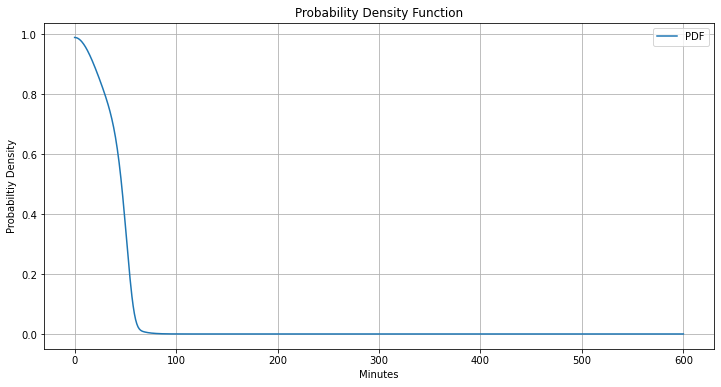

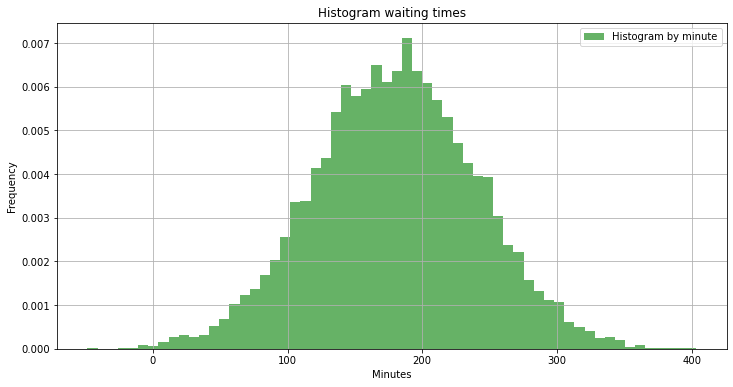

probability of waiting between 2 and 4 hours: 1.0351204040435125e-05
Mean waiting time: 3.0017598773678666 hours or 180.105592642072 minutes
variance of waiting time: 1.0130940701393392 hours^2 or 3647.138652501621 minutes^2
quartiles of waiting time: [2.3233034  3.00800121 3.68191481] hours or [139.3982042  180.48007261 220.91488854] minutes


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# probability density function:

def pdf(y):
    y= y/60 # convert minutes to hours
    return (0.35 * np.exp(-3 * y**2))+(0.64*np.exp(-3*y**8))

prob_between = integrate.quad(pdf, 2*60, 4*60)[0]
prob_between

#mean
d = np.random.normal(loc=3*60, scale=1*60,size=10000)
mean = np.mean(d) 
#variance
v = np.var(d) 
#quartile
q = np.percentile(d, [25, 50, 75]) 

#plot
x = np.linspace(0, 10*60, 1000)
y = pdf(x)
plt.figure(figsize=(12,6))
plt.plot(x,y,label='PDF')
plt.title('Probability Density Function')
plt.xlabel('Minutes')
plt.ylabel('Probabiltiy Density')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.hist(d,bins=60,density=True, alpha=0.6, color='g', label='Histogram by minute')
plt.title('Histogram waiting times')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"probability of waiting between 2 and 4 hours: {prob_between}")
print(f"Mean waiting time: {mean/60} hours or {mean} minutes")
print(f"variance of waiting time: {v/3600} hours^2 or {v} minutes^2")
print(f"quartiles of waiting time: {q/60} hours or {q} minutes")

In [31]:
# Task 3

Sample mean: 18.8
Estimated theta (MLE): 1.8800000000000001
Expected value E[T]: 18.8


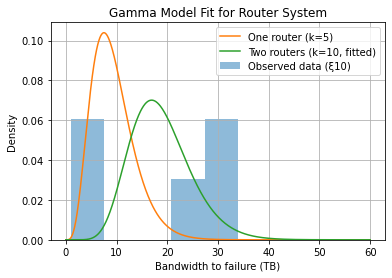

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma


# Given data (xi10)
data = np.array([34, 1, 7, 23, 29])

# Parameters
k1 = 5   # one router
k2 = 10  # two routers (system)

# Estimate theta (MLE)
mean_T = np.mean(data)
theta_hat = mean_T / k2

print("Sample mean:", mean_T)
print("Estimated theta (MLE):", theta_hat)

# Expectation
E_T = k2 * theta_hat
print("Expected value E[T]:", E_T)

# Range for plotting
x = np.linspace(0, 60, 1000)

# PDFs

pdf_one = gamma.pdf(x, a=k1, scale=theta_hat)   # one router
pdf_two = gamma.pdf(x, a=k2, scale=theta_hat)   # system (fitted)

# Plot
plt.figure()

# Histogram of data
plt.hist(data, bins=5, density=True, alpha=0.5, label="Observed data (ξ10)")

# Theoretical curves
plt.plot(x, pdf_one, label="One router (k=5)")
plt.plot(x, pdf_two, label="Two routers (k=10, fitted)")

# Labels
plt.xlabel("Bandwidth to failure (TB)")
plt.ylabel("Density")
plt.title("Gamma Model Fit for Router System")
plt.legend()
plt.grid()

plt.show()



In [33]:
# Task4

t-statistic: 1.1422729939543632
p-value: 0.1414089925107734


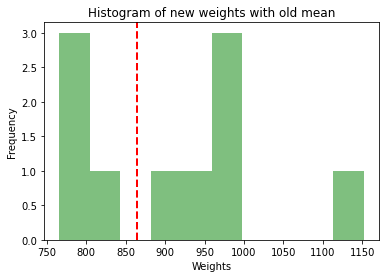

In [63]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
# Given data
old_mu = 865
old_sigma=92.8

new_weights = np.array([1152, 797, 926, 899, 766, 962, 783, 993, 969, 833])

# perform one sample t test 
t_stat, p_value = stats.ttest_1samp(new_weights, old_mu)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value/2}")

plt.hist(new_weights, bins=10, alpha = 0.5, color='g')
plt.axvline(old_mu, color='r', linestyle='dashed', linewidth=2)

plt.xlabel("Weights")
plt.ylabel("Frequency")
plt.title('Histogram of new weights with old mean')

plt.show()

In [35]:
#task 5

OLS coefficients:  [ 0.00000000e+00 -6.05723376e+11 -7.99831673e+10  5.12666008e+10
  8.87251355e+08 -1.02912198e+09  1.31212973e+07  7.91984033e+06
 -2.02291393e+05 -2.58809337e+04  8.37528266e+02  2.21869507e+01
 -1.06567383e+00]
Ridge coefficients:  [ 0.         -0.06047775  0.00471549 -0.09620622  0.00558173 -0.12036722
  0.00610326 -0.13647313  0.00633841 -0.14694728  0.00637761 -0.15364223
  0.00629108]


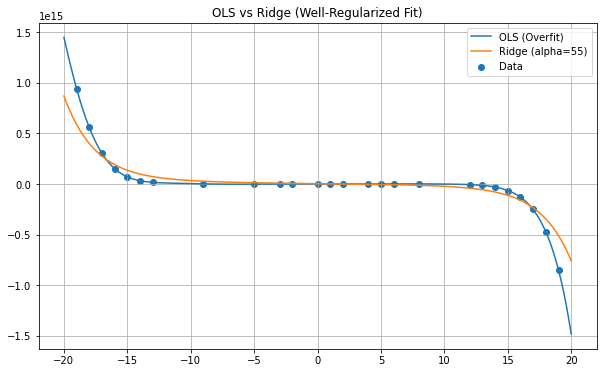

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Data
x = np.array([16, -2, 17, 19, 0, -18, 1, 4, -14, 8, -17, -15, 2, 18, -16, -3, 14, 15, 12, -5, 5, 13, -19, -13, 6, -9])
y = np.array([-132259329394539.6, 22374.49, -248055066326943.16, -849604628463469.1,-1.94, 558827647083055.4,
              -7.22, -23180304.26, 33618791975131.45, -61470480336.18, 302233101358295.06, 69926802370507.35, -3874.58,
              -477097959644525.25, 151596249195362.5, 1800413.11, -30230566472248.75, -67252754387416.14, -5337776826128.11,
              453232590.42, -301509842.55, -12646664734392.05, 940697721581776.1, 15842925669841.78, -2321961377.18,
              281617718317.71])

x = x.reshape(-1, 1)

# Polynomial features
poly = PolynomialFeatures(degree=12)
X_poly = poly.fit_transform(x)

# Scale X
scaler_X = StandardScaler()
X_poly_scaled = scaler_X.fit_transform(X_poly)

# Scale y
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# -------------------------
# OLS (for comparison)
# -------------------------
ols = LinearRegression()
ols.fit(X_poly, y)
print("OLS coefficients: ", ols.coef_)

# -------------------------
# Ridge (BEST fixed alpha)
# -------------------------
alpha = 55
ridge = Ridge(alpha=alpha)
ridge.fit(X_poly_scaled, y_scaled)
print("Ridge coefficients: ", ridge.coef_)

# -------------------------
# Plotting
# -------------------------
x_plot = np.linspace(-20, 20, 200).reshape(-1, 1)
X_plot_poly = poly.transform(x_plot)

# OLS prediction
y_plot_ols = ols.predict(X_plot_poly)

# Ridge prediction
X_plot_poly_scaled = scaler_X.transform(X_plot_poly)
y_plot_ridge_scaled = ridge.predict(X_plot_poly_scaled)
y_plot_ridge = scaler_y.inverse_transform(y_plot_ridge_scaled.reshape(-1, 1)).ravel()


plt.figure(figsize=(10,6))
plt.scatter(x, y, label='Data')
plt.plot(x_plot, y_plot_ols, label='OLS (Overfit)')
plt.plot(x_plot, y_plot_ridge, label=f'Ridge (alpha={alpha})')
plt.legend()
plt.title("OLS vs Ridge (Well-Regularized Fit)")
plt.grid()
plt.show()

In [37]:
import pandas as pd

df1 = pd.DataFrame({'OLS': ols.coef_, 'Ridge':ridge.coef_})
df1.round(5)

,OLS,Ridge
0,0.000000e+00,0.00000
1,-6.057234e+11,-0.06048
2,-7.998317e+10,0.00472
3,5.126660e+10,-0.09621
4,8.872514e+08,0.00558
5,-1.029122e+09,-0.12037
6,1.312130e+07,0.00610
7,7.919840e+06,-0.13647
8,-2.022914e+05,0.00634
9,-2.588093e+04,-0.14695


In [38]:
# Task6

In [65]:
import scipy.stats as stats
alpha_prior = 18
beta_prior = 50
alpha_likelihood = 3
beta_likelihood = 1/76.5
n=10
alpha_posterior = alpha_prior + n * alpha_likelihood
beta_posterior = beta_prior + n * beta_likelihood
posterior_distribution = stats.gamma(alpha_posterior, scale=1/beta_posterior)
bayes_estimate_mean = alpha_posterior / beta_posterior
bayes_estimate_mode = (alpha_posterior - 1) / beta_posterior
print("Posterior Distribution Parameters (Gamma):")
print("Alpha (𝛼) Posterior:", alpha_posterior)
print("Beta (𝛽) Posterior:", beta_posterior)
print("Bayes Point Estimate (Mean):", bayes_estimate_mean)
print("Bayes Point Estimate (Mode):", bayes_estimate_mode)

Posterior Distribution Parameters (Gamma):
Alpha (𝛼) Posterior: 48
Beta (𝛽) Posterior: 50.130718954248366
Bayes Point Estimate (Mean): 0.957496740547588
Bayes Point Estimate (Mode): 0.93754889178618
